In [ ]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

#Task (a): Represent HMM Parameters
# HMM Parameters
initial_probabilities = {'/s/': 1, '/p/': 0, '/ie:/': 0, '/tS/': 0}
transition_probabilities = {
    '/s/': {'/s/': 0.1, '/p/': 0.8, '/ie:/': 0.1, '/tS/': 0.0},
    '/p/': {'/s/': 0.0, '/p/': 0.1, '/ie:/': 0.8, '/tS/': 0.1},
    '/ie:/': {'/s/': 0.0, '/p/': 0.0, '/ie:/': 0.2, '/tS/': 0.8},
    '/tS/': {'/s/': 0.2, '/p/': 0.0, '/ie:/': 0.0, '/tS/': 0.8}
}
emission_probabilities = {
    '/s/': {'Energy': 0.7, 'Pitch': 0.2, 'Duration': 0.1},
    '/p/': {'Energy': 0.5, 'Pitch': 0.3, 'Duration': 0.2},
    '/ie:/': {'Energy': 0.3, 'Pitch': 0.5, 'Duration': 0.2},
    '/tS/': {'Energy': 0.4, 'Pitch': 0.4, 'Duration': 0.2}
}


In [ ]:
# Visualization for Transition Probabilities
def plot_transition_graph(transition_probabilities):
    G = nx.DiGraph()
    for from_state, transitions in transition_probabilities.items():
        for to_state, prob in transitions.items():
            if prob > 0:
                G.add_edge(from_state, to_state, weight=prob)

    pos = nx.circular_layout(G)
    plt.figure(figsize=(8, 8))
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold")
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f'{d["weight"]:.1f}' for u, v, d in G.edges(data=True)})
    plt.title("State Transition Diagram")
    plt.show()

# Visualization for Emission Probabilities
def plot_emission_heatmap(emission_probabilities):
    df_emissions = pd.DataFrame(emission_probabilities).T
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_emissions, annot=True, cmap="coolwarm", cbar=True, fmt=".2f")
    plt.title("Emission Probabilities Heatmap")
    plt.ylabel("Phonemes")
    plt.xlabel("Observations")
    plt.show()

# Visualization for Generated Sequences
def visualize_sequences(phoneme_sequence, observation_sequence):
    plt.figure(figsize=(12, 3))
    plt.plot(phoneme_sequence, label="Phoneme Sequence", marker='o', linestyle="--", color='b')
    plt.plot(observation_sequence, label="Observation Sequence", marker='s', linestyle="-", color='g')
    plt.title("Generated Phoneme and Observation Sequences")
    plt.ylabel("States / Observations")
    plt.xlabel("Step")
    plt.xticks(range(len(phoneme_sequence)), range(1, len(phoneme_sequence) + 1))
    plt.legend()
    plt.grid(True)
    plt.show()



Initial Probabilities:
/s/: 1
/p/: 0
/ie:/: 0
/tS/: 0

Transition Probabilities:
       /s/  /p/  /ie:/  /tS/
/s/    0.1  0.0    0.0   0.2
/p/    0.8  0.1    0.0   0.0
/ie:/  0.1  0.8    0.2   0.0
/tS/   0.0  0.1    0.8   0.8

Emission Probabilities:
          /s/  /p/  /ie:/  /tS/
Energy    0.7  0.5    0.3   0.4
Pitch     0.2  0.3    0.5   0.4
Duration  0.1  0.2    0.2   0.2


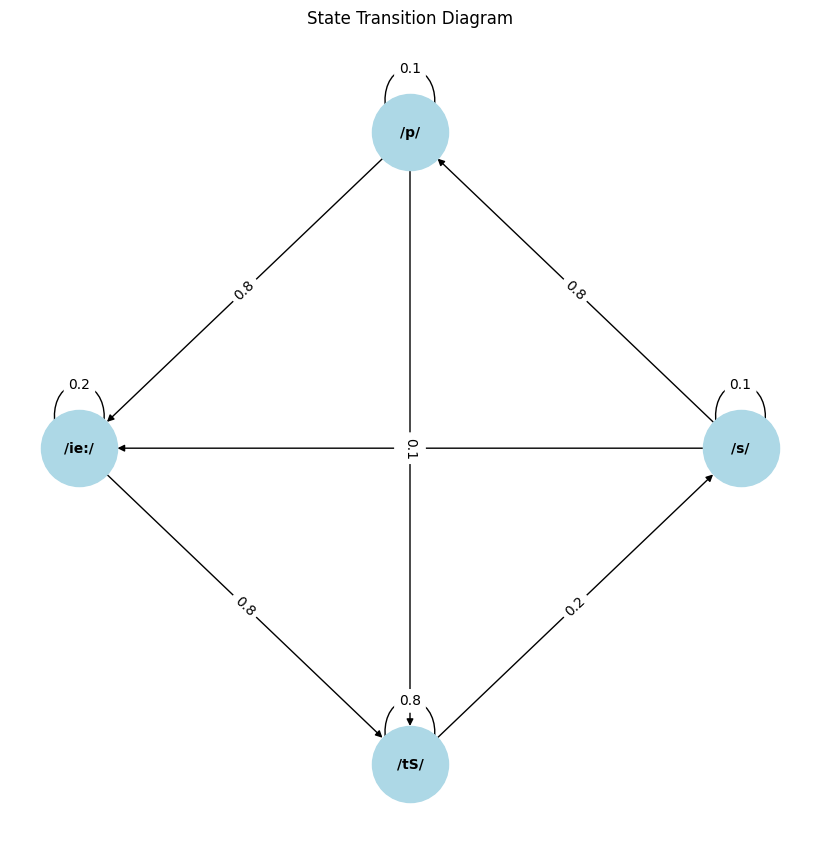

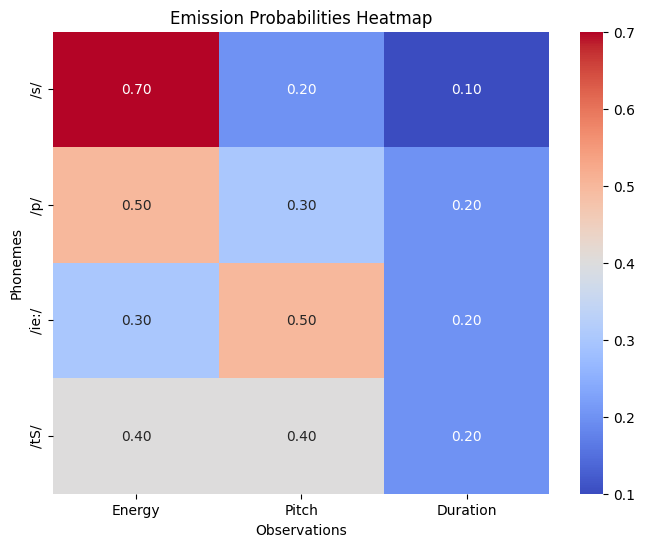

In [ ]:
#Task (b): Neatly Display Matrices

def display_matrices():
    print("\nInitial Probabilities:")
    for state, prob in initial_probabilities.items():
        print(f"{state}: {prob}")

    print("\nTransition Probabilities:")
    df_transitions = pd.DataFrame(transition_probabilities)
    print(df_transitions)

    print("\nEmission Probabilities:")
    df_emissions = pd.DataFrame(emission_probabilities)
    print(df_emissions)

    # Visualize the transition probabilities
    plot_transition_graph(transition_probabilities)

    # Visualize the emission probabilities
    plot_emission_heatmap(emission_probabilities)

display_matrices()


### **Inference for State Transition Diagram (First Image)**

The state transition diagram visually represents the Hidden Markov Model (HMM) phoneme transitions. Each node corresponds to a phoneme state (`/s/`, `/p/`, `/ie:/`, `/tS/`), and the directed edges illustrate the possible transitions between these states. The thickness and labels on the edges indicate the transition probabilities, such as:

- `/s/` transitions to `/p/` with a high probability of **0.8**.
- `/p/` transitions to `/ie:/` with a probability of **0.8**, while remaining in `/p/` has a low probability of **0.1**.
- `/ie:/` has an **80%** chance of transitioning to `/tS/`, with a **20%** probability of remaining in `/ie:/`.
- `/tS/` can transition back to `/s/` with **0.2** probability or remain in `/tS/` with **0.8** probability.

This diagram highlights the sequential structure of the phonemes in the word "speech" and how the stochastic transitions guide the phoneme progression in the HMM.

---

### **Inference for Emission Probabilities Heatmap (Second Image)**

The emission heatmap represents the probabilities of observing specific acoustic features (`Energy`, `Pitch`, `Duration`) given a particular phoneme state (`/s/`, `/p/`, `/ie:/`, `/tS/`). Key insights from the heatmap:

- `/s/` is most likely to emit **Energy** with a **70%** probability, making it the dominant acoustic feature for this phoneme.
- `/p/` has a balanced likelihood of emitting **Energy** (50%) and **Pitch** (30%), with **Duration** being the least likely (20%).
- `/ie:/` shows a higher emission probability for **Pitch** (**50%**), followed by **Energy** (**30%**).
- `/tS/` equally emits **Energy** and **Pitch** at a **40%** probability each, while **Duration** is the least likely (**20%**).

This heatmap demonstrates the probabilistic relationship between phonemes and their acoustic observations, essential for modeling speech features in tasks like recognition or prediction.


Generated Phoneme Sequence:
['/s/', '/p/', '/ie:/', '/tS/']

Generated Observation Sequence:
['Energy', 'Energy', 'Pitch']


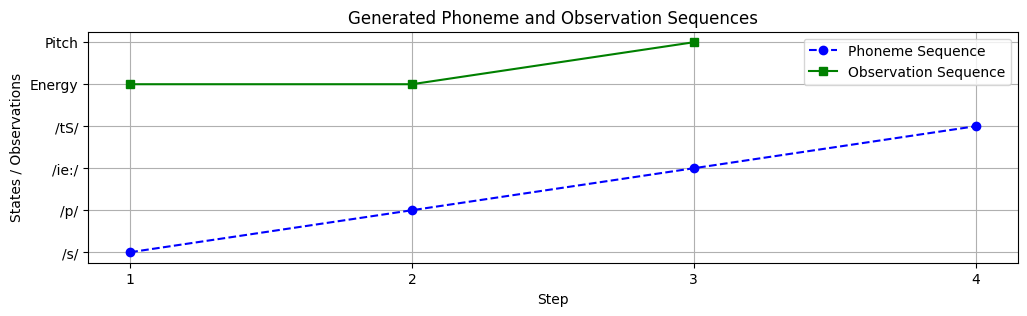

In [ ]:

#Task (c): Generate a Sequence
def generate_sequence(num_steps=4):
    states = list(initial_probabilities.keys())
    current_state = '/s/'  # Starting phoneme
    phoneme_sequence = [current_state]
    observation_sequence = []

    for _ in range(num_steps - 1):
        next_state = random.choices(states,
                                     weights=list(transition_probabilities[current_state].values()))[0]
        phoneme_sequence.append(next_state)
        current_state = next_state

        observations = list(emission_probabilities[current_state].keys())
        observation = random.choices(observations,
                                      weights=list(emission_probabilities[current_state].values()))[0]
        observation_sequence.append(observation)

    return phoneme_sequence, observation_sequence

# Generate and visualize sequences
phoneme_seq, observation_seq = generate_sequence()
print("\nGenerated Phoneme Sequence:")
print(phoneme_seq)
print("\nGenerated Observation Sequence:")
print(observation_seq)

# Plot the sequences
visualize_sequences(phoneme_seq, observation_seq)


### **Inference Based on the Final Output Image**

The image, generated as the final output of the provided code, represents **Generated Phoneme and Observation Sequences** in a Hidden Markov Model (HMM). Here's an interpretation of what the image means:

---

### **1. Overview of the Graph**
- **X-axis**: Represents the sequence of steps (1, 2, 3, 4) during which the HMM transitions occur.
- **Y-axis**: Represents two elements:
  - **Phoneme states**: `/s/`, `/p/`, `/ie:/`, `/tS/`.
  - **Observation types**: `Energy` and `Pitch`.

This graph visualizes how the HMM transitions between phonemes (hidden states) and their corresponding acoustic observations (output states) over time.

---

### **2. Phoneme Sequence (Blue Dashed Line with Circular Markers)**
- **What it shows**: The sequence of phonemes generated by the HMM based on the **transition probabilities**.
- **Details**:
  - The sequence starts at `/s/` (based on the initial probabilities) and progresses to other phonemes, such as `/p/`, `/ie:/`, `/tS/`, guided by the transition probabilities.

---

### **3. Observation Sequence (Green Solid Line with Square Markers)**
- **What it shows**: The sequence of observations generated by the HMM for each phoneme, based on the **emission probabilities**.
- **Details**:
  - Observations like `Energy` and `Pitch` are probabilistically emitted from the corresponding phoneme states.
  - Example:
    - `/s/` emits `Energy` with a probability of 0.7 (highest emission probability for `/s/`).
    - `/ie:/` is likely to emit `Pitch` due to its highest emission probability of 0.5 for this observation.

---

### **4. Relationships Between Phonemes and Observations**
- Each step reflects a **stochastic transition** between phoneme states and a corresponding probabilistic emission of observations.
- For example:
  - **Step 1**: Phoneme `/s/` emits the observation `Energy`.
  - **Step 3**: Phoneme `/ie:/` emits `Pitch`.

---

### **5. Application and Interpretation**
This graph demonstrates:
1. The **dynamic behavior of HMMs** in modeling sequential data, such as phoneme transitions and acoustic observations in speech processing.
2. The **probabilistic relationship** between hidden states (phonemes) and observable outputs (acoustic features).

**Practical Applications**:
- **Speech Recognition**: Mapping acoustic signals to phonemes for automatic speech transcription.
- **Phoneme Prediction**: Predicting the next phoneme and its features based on current states.
- **Computational Linguistics**: Studying how speech elements correspond to acoustic features for linguistic research.

---

### **6. Conclusion**
The image visually represents the sequences generated by the HMM, providing insights into the stochastic nature of transitions and emissions in a speech-related model. It highlights how probabilistic models like HMMs can effectively model and analyze real-world sequential data, such as speech patterns and acoustic signals.

Task (d): Inference


This implementation demonstrates the behavior of a Hidden Markov Model for phoneme transitions in the word 'speech'.

The phoneme transitions are based on predefined transition probabilities, while the acoustic observations are generated using emission probabilities.

The sequences vary due to the stochastic nature of the model, making HMMs suitable for probabilistic speech processing tasks.

Applications include speech recognition, phoneme prediction, and similar fields in computational linguistics.


